# 04 — Multi-asset extension (SPY / TLT / GLD)

Loads the outputs of `experiments/run_regime_comparison.py configs/multiasset.yaml` and `run_robustness.py`. Each asset is gated by its **own** independently fitted regime model; baselines are equal-weight. OOS window: 2009-12 → 2026-06.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from regimelab import plotting

FIG = ROOT / "reports" / "figures"
OUT = ROOT / "experiments" / "outputs" / "multiasset"
net = pd.read_csv(OUT / "net_returns.csv", index_col=0, parse_dates=True)
summary = pd.read_csv(OUT / "summary.csv", index_col=0)
boot = pd.read_csv(OUT / "bootstrap_sharpe_diffs.csv", index_col=0)
at5 = summary.loc[summary.index.str.endswith("@5bps")].copy()
at5.index = at5.index.str.replace("@5bps", "")
at5[["ann_return", "ann_volatility", "sharpe", "max_drawdown",
     "avg_annual_turnover"]].sort_values("sharpe", ascending=False).round(3)

,ann_return,ann_volatility,sharpe,max_drawdown,avg_annual_turnover
strategy,,,,,
vol20q80_bh,0.073,0.075,0.975,-0.127,4.995
buy_and_hold,0.089,0.093,0.958,-0.227,0.061
hmm2p_bh,0.060,0.068,0.884,-0.126,11.251
vol20q80_trend,0.052,0.061,0.863,-0.157,9.160
hmm2_bh,0.057,0.073,0.799,-0.155,9.524
trend_200d,0.054,0.072,0.764,-0.149,8.351
hmm2_trend,0.042,0.059,0.735,-0.179,11.081


PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/multiasset_wealth.png')

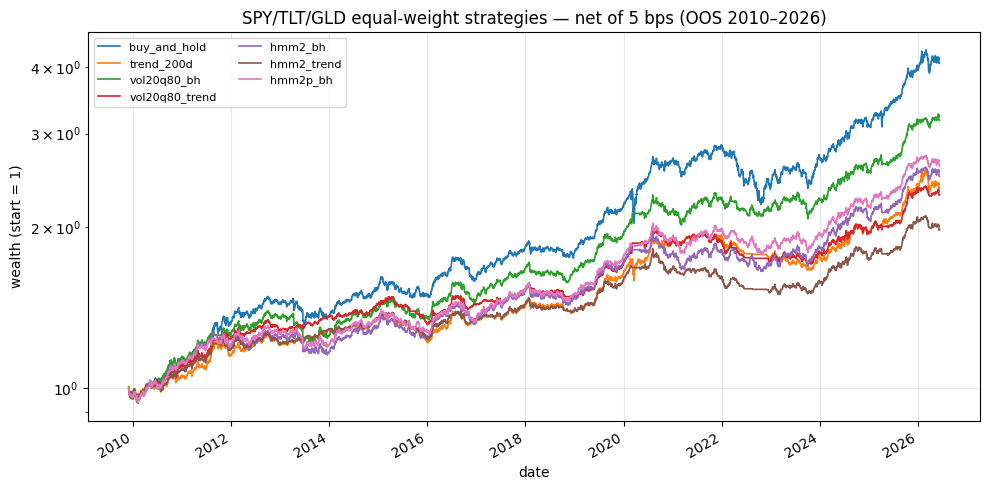

In [2]:
fig = plotting.wealth_curves(net, title="SPY/TLT/GLD equal-weight strategies — net of 5 bps (OOS 2010–2026)")
plotting.save_figure(fig, FIG / "multiasset_wealth.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/multiasset_bootstrap.png')

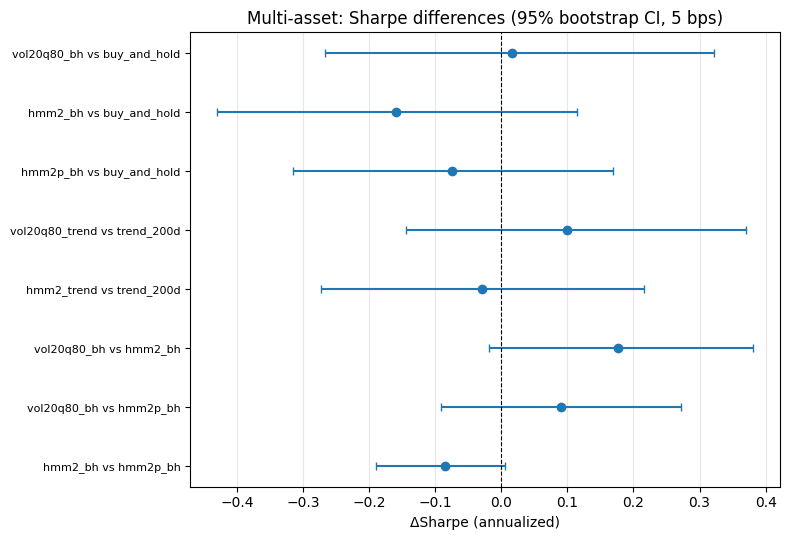

In [3]:
fig = plotting.bootstrap_forest(boot, title="Multi-asset: Sharpe differences (95% bootstrap CI, 5 bps)")
plotting.save_figure(fig, FIG / "multiasset_bootstrap.png")

In [4]:
# Per-asset turbulent shares under each regime model.
shares = {}
for name in ["vol20q80", "hmm2"]:
    labels = pd.read_csv(OUT / f"regimes_{name}.csv", index_col=0, parse_dates=True)
    shares[name] = labels.apply(lambda s: (s > 0).mean())
pd.DataFrame(shares).round(3)

,vol20q80,hmm2
SPY,0.162,0.155
TLT,0.219,0.287
GLD,0.098,0.108


**Reading.** The headline result is *negative and informative*: the diversified equal-weight portfolio already has Sharpe ≈ 0.96 and max drawdown −23%, and per-asset regime gating does **not** improve it (vol gate ΔSharpe +0.02; the HMM gate *hurts*, −0.16, by trading bond and gold noise). Regime gating earned its keep on a concentrated equity portfolio; diversification already does most of that risk-control job here. Soft probability scaling (`hmm2p_bh`) beats the hard HMM gate (bootstrap P(≤0) ≈ 0.97 for hard−soft), confirming the single-asset finding that hard thresholding amplifies state flicker.